In [22]:
# Cellule 1: Installation des dépendances
!pip install kagglehub pandas numpy scikit-learn matplotlib seaborn opencv-python tqdm torch torchvision -q

# Imports
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
from tqdm import tqdm
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

print("✅ Toutes les bibliothèques sont installées!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")

✅ Toutes les bibliothèques sont installées!
PyTorch version: 2.10.0+cpu
CUDA disponible: False


In [23]:
# Cellule 2: Configuration et chargement des données
print("\n📁 Chargement du dataset HAM10000...")

# Détecter l'emplacement du dataset
kaggle_path = "/kaggle/input/skin-cancer-mnist-ham10000"
if os.path.exists(kaggle_path):
    dataset_path = kaggle_path
    print(f"✓ Dataset trouvé dans Kaggle: {dataset_path}")
else:
    print("📥 Téléchargement via KaggleHub...")
    import kagglehub
    dataset_path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
    print(f"✓ Dataset téléchargé: {dataset_path}")

# Cartographier toutes les images
print("\n🖼️ Cartographie des images...")
image_paths = {}
for root, _, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith('.jpg'):
            img_id = os.path.splitext(file)[0]
            image_paths[img_id] = os.path.join(root, file)

print(f"✓ {len(image_paths)} images JPEG trouvées")

# Charger les métadonnées
metadata_file = glob.glob(os.path.join(dataset_path, "**/HAM10000_metadata.csv"), recursive=True)
if metadata_file:
    metadata = pd.read_csv(metadata_file[0])
    print(f"✓ Métadonnées chargées: {len(metadata)} entrées")
else:
    raise FileNotFoundError("Fichier de métadonnées non trouvé!")

# Vérifier l'existence des images
metadata['exists'] = metadata['image_id'].isin(image_paths)
metadata = metadata[metadata['exists']].reset_index(drop=True)
print(f"✓ Dataset final: {len(metadata)} images")

# Afficher les premières lignes
print("\n📊 Aperçu des données:")
print(metadata.head())


📁 Chargement du dataset HAM10000...
✓ Dataset trouvé dans Kaggle: /kaggle/input/skin-cancer-mnist-ham10000

🖼️ Cartographie des images...
✓ 10015 images JPEG trouvées
✓ Métadonnées chargées: 10015 entrées
✓ Dataset final: 10015 images

📊 Aperçu des données:
     lesion_id      image_id   dx dx_type   age   sex localization  exists
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp    True
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp    True
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp    True
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp    True
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear    True


📊 Distribution des classes:
Nævus mélanocytaire       | █████████████████████████████████ | 6705 (66.9%)
Mélanome                  | █████                          | 1113 (11.1%)
Kératose bénigne          | █████                          | 1099 (11.0%)
Carcinome basocellulaire  | ██                             |  514 (5.1%)
Kératose actinique        | █                              |  327 (3.3%)
Lésions vasculaires       |                                |  142 (1.4%)
Dermatofibrome            |                                |  115 (1.1%)


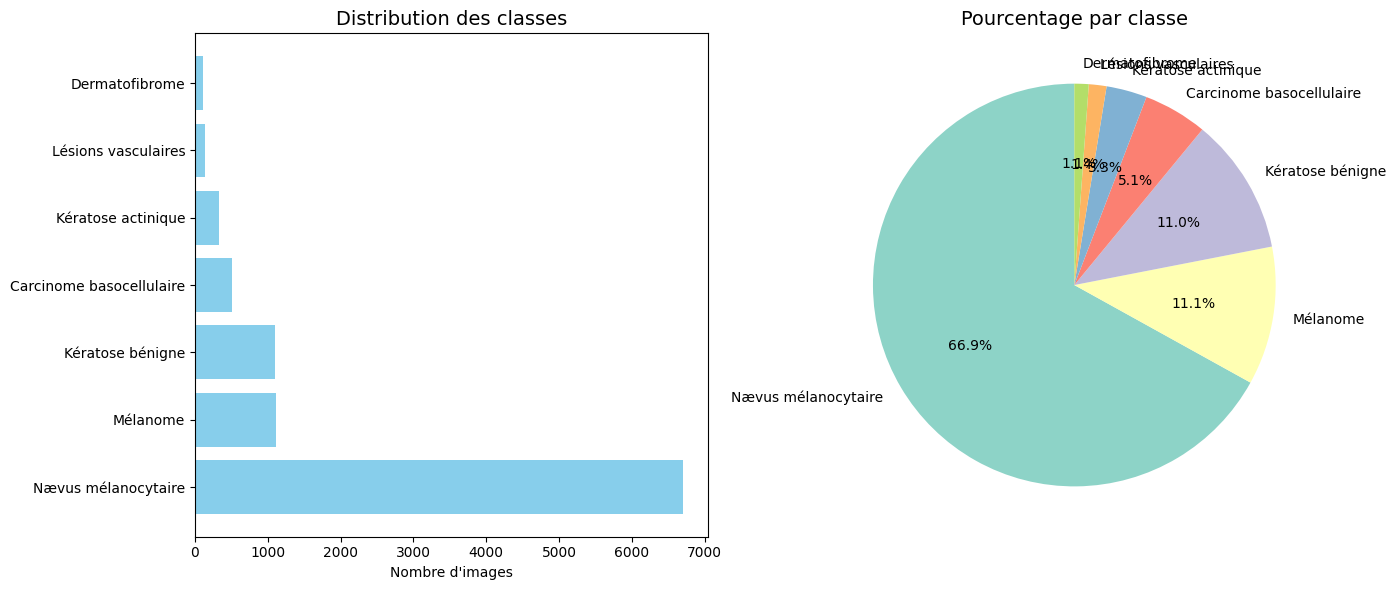

In [24]:
# Cellule 3: Analyse exploratoire et visualisation

# Noms des classes en français
class_names_fr = {
    'akiec': 'Kératose actinique',
    'bcc': 'Carcinome basocellulaire',
    'bkl': 'Kératose bénigne',
    'df': 'Dermatofibrome',
    'mel': 'Mélanome',
    'nv': 'Nævus mélanocytaire',
    'vasc': 'Lésions vasculaires'
}

# Encodage des labels
label_encoder = LabelEncoder()
metadata['label'] = label_encoder.fit_transform(metadata['dx'])
class_names = list(label_encoder.classes_)
class_names_fr_list = [class_names_fr[c] for c in class_names]

# Distribution des classes
class_counts = metadata['dx'].value_counts()
print("📊 Distribution des classes:")
print("="*50)
for cls, count in class_counts.items():
    percentage = count/len(metadata)*100
    bar = '█' * int(percentage / 2)
    print(f"{class_names_fr[cls]:25} | {bar:30} | {count:4} ({percentage:.1f}%)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
axes[0].barh(range(len(class_counts)), class_counts.values, color='skyblue')
axes[0].set_yticks(range(len(class_counts)))
axes[0].set_yticklabels([class_names_fr[cls] for cls in class_counts.index])
axes[0].set_xlabel("Nombre d'images")
axes[0].set_title('Distribution des classes', fontsize=14)

# Pie chart
colors = plt.cm.Set3(range(len(class_counts)))
axes[1].pie(class_counts.values, labels=[class_names_fr[cls] for cls in class_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Pourcentage par classe', fontsize=14)

plt.tight_layout()
plt.show()

In [25]:
# Cellule 4: Définition des transformations (optimisées pour CPU)

# Note: Les transformations sont moins lourdes car on est sur CPU
train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Transformations pour la validation/test (sans augmentation)
val_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("✅ Transformations définies (optimisées CPU)")
print(f"  - Entraînement: {len(train_transforms.transforms)} transformations")
print(f"  - Validation: {len(val_transforms.transforms)} transformations")

✅ Transformations définies (optimisées CPU)
  - Entraînement: 8 transformations
  - Validation: 4 transformations


In [26]:
# Cellule 5: Dataset avec équilibrage des classes

class BalancedSkinDataset(Dataset):
    def __init__(self, metadata, image_paths, transform=None, is_train=True):
        self.metadata = metadata.reset_index(drop=True)
        self.image_paths = image_paths
        self.transform = transform
        self.is_train = is_train

        # Identifier les classes minoritaires
        class_counts = self.metadata['dx'].value_counts()
        self.minority_classes = class_counts[class_counts < 500].index.tolist()

        # Calculer les poids pour le sur-échantillonnage
        sample_weights = []
        for _, row in self.metadata.iterrows():
            weight = 1.0 / class_counts[row['dx']]
            sample_weights.append(weight)
        self.sample_weights = sample_weights

        print(f"📊 Dataset initialisé:")
        print(f"  - Total images: {len(self.metadata)}")
        print(f"  - Classes minoritaires: {self.minority_classes}")

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        img_id = row['image_id']
        label = row['label']

        # Charger l'image
        img_path = self.image_paths.get(img_id)
        if img_path is None:
            base_dir = os.path.dirname(list(self.image_paths.values())[0])
            possible_path = os.path.join(base_dir, f"{img_id}.jpg")
            if os.path.exists(possible_path):
                img_path = possible_path
            else:
                for root, _, files in os.walk(base_dir):
                    if f"{img_id}.jpg" in files:
                        img_path = os.path.join(root, f"{img_id}.jpg")
                        break

        if img_path is None:
            raise FileNotFoundError(f"Image {img_id}.jpg non trouvée!")

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Augmentations légères pour classes minoritaires (CPU friendly)
        if self.is_train and row['dx'] in self.minority_classes:
            image = self._augment_light(image)

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

    def _augment_light(self, image):
        """Augmentations légères pour CPU"""
        h, w = image.shape[:2]

        # Rotation (optionnelle)
        if np.random.random() > 0.5:
            angle = np.random.uniform(-30, 30)
            M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1)
            image = cv2.warpAffine(image, M, (w, h))

        # Flip horizontal
        if np.random.random() > 0.5:
            image = cv2.flip(image, 1)

        return image

print("✅ Classe BalancedSkinDataset créée")

✅ Classe BalancedSkinDataset créée


In [27]:
# Cellule 6: Division des données et DataLoaders (optimisé CPU)

print("\n📊 Division des données...")

# Split avec stratification
train_idx, temp_idx = train_test_split(
    range(len(metadata)),
    test_size=0.3,
    stratify=metadata['dx'],
    random_state=42
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=metadata.iloc[temp_idx]['dx'],
    random_state=42
)

# Création des DataFrames
metadata_train = metadata.iloc[train_idx].reset_index(drop=True)
metadata_val = metadata.iloc[val_idx].reset_index(drop=True)
metadata_test = metadata.iloc[test_idx].reset_index(drop=True)

print(f"\n📈 Taille des ensembles:")
print(f"  - Train: {len(metadata_train)} images ({len(metadata_train)/len(metadata)*100:.1f}%)")
print(f"  - Validation: {len(metadata_val)} images ({len(metadata_val)/len(metadata)*100:.1f}%)")
print(f"  - Test: {len(metadata_test)} images ({len(metadata_test)/len(metadata)*100:.1f}%)")

# Création des datasets
train_dataset = BalancedSkinDataset(metadata_train, image_paths, transform=train_transforms, is_train=True)
val_dataset = BalancedSkinDataset(metadata_val, image_paths, transform=val_transforms, is_train=False)
test_dataset = BalancedSkinDataset(metadata_test, image_paths, transform=val_transforms, is_train=False)

# Calcul des poids pour le sampler
class_counts_train = metadata_train['dx'].value_counts()
sample_weights = [1.0 / class_counts_train[row['dx']] for _, row in metadata_train.iterrows()]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# DataLoaders avec batch size réduit pour CPU
batch_size = 16  # Réduit pour CPU
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

print(f"\n✅ DataLoaders créés (mode CPU):")
print(f"  - Batch size: {batch_size}")
print(f"  - Train batches: {len(train_loader)}")
print(f"  - Validation batches: {len(val_loader)}")
print(f"  - Test batches: {len(test_loader)}")


📊 Division des données...

📈 Taille des ensembles:
  - Train: 7010 images (70.0%)
  - Validation: 1502 images (15.0%)
  - Test: 1503 images (15.0%)
📊 Dataset initialisé:
  - Total images: 7010
  - Classes minoritaires: ['bcc', 'akiec', 'vasc', 'df']
📊 Dataset initialisé:
  - Total images: 1502
  - Classes minoritaires: ['mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']
📊 Dataset initialisé:
  - Total images: 1503
  - Classes minoritaires: ['mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']

✅ DataLoaders créés (mode CPU):
  - Batch size: 16
  - Train batches: 439
  - Validation batches: 94
  - Test batches: 94


In [28]:
# Cellule 7: Modèle (CORRIGÉ)

class FocalLoss(nn.Module):
    """Focal Loss pour datasets déséquilibrés"""
    def __init__(self, alpha=1, gamma=2, class_weights=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.class_weights = class_weights

    def forward(self, inputs, targets):
        # S'assurer que les targets sont en long
        targets = targets.long()

        ce_loss = nn.CrossEntropyLoss(weight=self.class_weights, reduction='none')(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * ce_loss
        return focal_loss.mean()

print("🏗️ Construction du modèle (optimisé CPU)...")

# Modèle EfficientNet-B0
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Modification de la dernière couche
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, len(class_names))

# Calcul des poids des classes (convertir en float32)
class_counts_all = metadata['dx'].value_counts()
class_weights = torch.tensor([1.0 / class_counts_all[cls] for cls in class_names], dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * len(class_names)

print(f"✅ Modèle créé:")
print(f"  - Architecture: EfficientNet-B0")
print(f"  - Classes: {len(class_names)}")
print(f"  - Poids des classes: {class_weights.numpy().round(3)}")

# Loss et optimizer
criterion = FocalLoss(gamma=2, class_weights=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print(f"✅ Optimizer configuré")

🏗️ Construction du modèle (optimisé CPU)...
✅ Modèle créé:
  - Architecture: EfficientNet-B0
  - Classes: 7
  - Poids des classes: [0.943 0.6   0.281 2.682 0.277 0.046 2.172]
✅ Optimizer configuré


In [29]:
# Cellule 8: Fonctions d'entraînement (CORRIGÉES)

def train_epoch(model, loader, criterion, optimizer):
    """Entraîne le modèle pour une époque"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Entraînement")
    for images, labels in progress_bar:
        # Convertir les labels en int64 (PyTorch attend LongTensor pour les labels)
        labels = labels.long()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # Mettre à jour la barre de progression
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })

    return total_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion):
    """Valide le modèle"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        progress_bar = tqdm(loader, desc="Validation")
        for images, labels in progress_bar:
            # Convertir les labels en int64
            labels = labels.long()

            outputs = model(images)
            loss = criterion(outputs, labels)
            probs = torch.softmax(outputs, dim=1)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

            progress_bar.set_postfix({'acc': f'{100.*correct/total:.2f}%'})

    return total_loss / len(loader), 100. * correct / total, all_preds, all_labels, all_probs

print("✅ Fonctions d'entraînement corrigées")

✅ Fonctions d'entraînement corrigées


In [ ]:
# Cellule 9: Entraînement (CORRIGÉ - Version CPU)

print("\n🚀 DÉBUT DE L'ENTRAÎNEMENT (Mode CPU)")
print("⚠️ L'entraînement peut être lent sur CPU - patience requise!")
print("="*60)

num_epochs = 20
best_val_acc = 0
best_model_path = "best_skin_cancer_model.pth"

# Historiques
train_losses = []
val_losses = []
train_accs = []
val_accs = []

# Convertir les poids des classes en float32 (CORRECTION)
class_weights_float32 = class_weights.to(dtype=torch.float32)

# Recréer le critère avec les bons types (CORRECTION)
criterion = FocalLoss(gamma=2, class_weights=class_weights_float32)

for epoch in range(num_epochs):
    print(f"\n📊 Epoch {epoch+1}/{num_epochs}")
    print("-" * 40)

    # Entraînement
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)

    # Validation
    val_loss, val_acc, val_preds, val_labels, val_probs = validate(model, val_loader, criterion)

    # Mise à jour du learning rate
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # Sauvegarde des historiques
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Affichage des résultats
    print(f"\n📈 Résultats Epoch {epoch+1}:")
    print(f"  Train - Loss: {train_loss:.4f}, Accuracy: {train_acc:.2f}%")
    print(f"  Val   - Loss: {val_loss:.4f}, Accuracy: {val_acc:.2f}%")
    print(f"  LR: {current_lr:.6f}")

    # Sauvegarde du meilleur modèle
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"  ✅ Meilleur modèle sauvegardé! (Accuracy: {val_acc:.2f}%)")

    # Early stopping
    if epoch > 5 and len(val_accs) >= 3:
        if val_accs[-1] - val_accs[-3] < 0.5 and val_accs[-1] < 70:
            print(f"\n⚠️ Early stopping - Plus d'amélioration significative")
            break

print(f"\n✅ ENTRAÎNEMENT TERMINÉ!")
print(f"  Meilleure validation accuracy: {best_val_acc:.2f}%")
print(f"  Modèle sauvegardé: {best_model_path}")


🚀 DÉBUT DE L'ENTRAÎNEMENT (Mode CPU)
⚠️ L'entraînement peut être lent sur CPU - patience requise!

📊 Epoch 1/20
----------------------------------------


Entraînement:  10%|▉         | 42/439 [03:15<28:58,  4.38s/it, loss=0.2135, acc=22.92%]

In [ ]:
# Cellule 10: Visualisation des performances

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Courbes de loss
axes[0].plot(train_losses, label='Train Loss', marker='o', linewidth=2, markersize=4)
axes[0].plot(val_losses, label='Validation Loss', marker='s', linewidth=2, markersize=4)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Courbes de Loss', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Courbes d'accuracy
axes[1].plot(train_accs, label='Train Accuracy', marker='o', linewidth=2, markersize=4)
axes[1].plot(val_accs, label='Validation Accuracy', marker='s', linewidth=2, markersize=4)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Courbes d\'Accuracy', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Courbes d'apprentissage sauvegardées")

In [ ]:
# Cellule 11: Évaluation sur l'ensemble de test

print("\n📊 ÉVALUATION SUR L'ENSEMBLE DE TEST")
print("="*50)

# Charger le meilleur modèle
model.load_state_dict(torch.load(best_model_path))
test_loss, test_acc, test_preds, test_labels, test_probs = validate(model, test_loader, criterion)

print(f"\n📈 Résultats sur le test set:")
print(f"  - Loss: {test_loss:.4f}")
print(f"  - Accuracy: {test_acc:.2f}%")

# Matrice de confusion
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_fr_list,
            yticklabels=class_names_fr_list,
            annot_kws={'size': 10})
plt.title('Matrice de Confusion - Test Set', fontsize=14)
plt.xlabel('Prédiction', fontsize=12)
plt.ylabel('Vérité terrain', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Rapport de classification
print("\n📋 Rapport de classification détaillé:")
print("="*60)
print(classification_report(test_labels, test_preds,
                          target_names=class_names_fr_list,
                          digits=3))

In [ ]:
# Cellule 12: Sauvegarde du modèle et métadonnées

import pickle

# Sauvegarder le modèle
model_path = "skin_cancer_model_cpu.pth"
torch.save(model.state_dict(), model_path)
print(f"✅ Modèle sauvegardé: {model_path}")

# Sauvegarder les métadonnées
inference_data = {
    'class_names': class_names_fr_list,
    'class_names_en': class_names,
    'transform_params': {
        'size': 224,
        'mean': [0.485, 0.456, 0.406],
        'std': [0.229, 0.224, 0.225]
    },
    'model_architecture': 'efficientnet_b0',
    'best_accuracy': best_val_acc,
    'test_accuracy': test_acc
}

with open('inference_metadata_cpu.pkl', 'wb') as f:
    pickle.dump(inference_data, f)

print(f"✅ Métadonnées sauvegardées: inference_metadata_cpu.pkl")

# Créer un fichier ZIP
import zipfile

with zipfile.ZipFile('skin_cancer_model_cpu.zip', 'w') as zipf:
    zipf.write(model_path)
    zipf.write('inference_metadata_cpu.pkl')
    zipf.write(best_model_path)

print(f"✅ Modèles compressés dans skin_cancer_model_cpu.zip")

# Télécharger (pour Colab)
try:
    from google.colab import files
    files.download('skin_cancer_model_cpu.zip')
    print("\n🎉 Téléchargement démarré!")
except:
    print("\n🎉 Modèle prêt! Fichiers disponibles localement.")

print("\n✅ TRAITEMENT TERMINÉ!")

In [ ]:
# Cellule 13: Test de prédiction (version CPU)

def predict_skin_lesion(image_path, model, transform, class_names_fr_list, threshold=0.7):
    """
    Prédit le type de lésion cutanée à partir d'une image
    """
    model.eval()

    # Charger l'image
    if isinstance(image_path, str):
        image = cv2.imread(image_path)
    else:
        image = image_path

    if image is None:
        raise ValueError("Impossible de charger l'image")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Prétraitement
    image = transform(image)
    image = image.unsqueeze(0)  # Pas besoin de .to(device) sur CPU

    # Prédiction
    with torch.no_grad():
        outputs = model(image)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

        conf = confidence.item()
        pred_class = class_names_fr_list[predicted.item()]
        all_probs = probabilities[0].cpu().numpy()

        # Si confiance trop faible, signaler
        if conf < threshold:
            return "Non reconnu", conf, all_probs, False

        return pred_class, conf, all_probs, True

# Test sur quelques images du test set
print("\n🔬 Test de prédiction sur 5 échantillons:")
print("="*60)

test_samples = test_dataset.metadata.head(5)
for idx, row in test_samples.iterrows():
    img_id = row['image_id']
    true_label = class_names_fr[row['dx']]

    # Trouver le chemin de l'image
    img_path = image_paths.get(img_id)
    if img_path and os.path.exists(img_path):
        pred, conf, probs, confident = predict_skin_lesion(
            img_path, model, val_transforms, class_names_fr_list, threshold=0.7
        )

        status = "✅" if pred == true_label else "❌"
        print(f"{status} {true_label:30} -> {pred:30} (conf: {conf:.2%})")
    else:
        print(f"⚠️ Image {img_id} non trouvée")

print("\n✅ Modèle prêt pour la prédiction!")

In [ ]:
# Cellule 14: Sauvegarde du modèle pour utilisation future

import pickle

# Sauvegarder le modèle entraîné
model_path = "skin_cancer_model_final.pth"
torch.save(model.state_dict(), model_path)
print(f"✅ Modèle sauvegardé: {model_path}")

# Sauvegarder les métadonnées nécessaires pour l'inférence
inference_data = {
    'class_names': class_names_fr_list,
    'class_names_en': class_names,
    'transform_params': {
        'size': 224,
        'mean': [0.485, 0.456, 0.406],
        'std': [0.229, 0.224, 0.225]
    },
    'model_architecture': 'efficientnet_b0',
    'best_accuracy': best_val_acc,
    'test_accuracy': test_acc,
    'num_classes': len(class_names)
}

with open('inference_metadata.pkl', 'wb') as f:
    pickle.dump(inference_data, f)

print(f"✅ Métadonnées sauvegardées: inference_metadata.pkl")

# Compresser les fichiers pour téléchargement
import zipfile

with zipfile.ZipFile('skin_cancer_model_complete.zip', 'w') as zipf:
    zipf.write(model_path)
    zipf.write('inference_metadata.pkl')
    zipf.write(best_model_path)
    print(f"  - Ajouté: {model_path}")
    print(f"  - Ajouté: inference_metadata.pkl")
    print(f"  - Ajouté: {best_model_path}")

print(f"\n✅ Modèles compressés dans skin_cancer_model_complete.zip")

# Télécharger (pour Google Colab)
try:
    from google.colab import files
    print("\n📥 Démarrage du téléchargement...")
    files.download('skin_cancer_model_complete.zip')
    print("✅ Téléchargement terminé!")
except:
    print("\n⚠️ Non exécuté dans Colab - fichiers disponibles localement")

print("\n" + "="*60)
print("🎉 ENTRAÎNEMENT ET SAUVEGARDE TERMINÉS!")
print("="*60)
print("\n📁 Fichiers générés:")
print("   - skin_cancer_model_final.pth (poids du modèle)")
print("   - inference_metadata.pkl (métadonnées)")
print("   - best_skin_cancer_model.pth (meilleur modèle)")
print("   - skin_cancer_model_complete.zip (tous les fichiers compressés)")
print("\n💡 Ces fichiers sont nécessaires pour l'application Streamlit!")